<h1>Compiled codes of each algorithms</h1>
<h3>Please don't run the file as some algorithms may take a very very long time to run.</h3>

In [4]:
import pandas as pd
import numpy as np
import random
import warnings
# Suppress all warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from IPython.display import Image, display
np.random.seed(4014) 
#graphs shown will be different from the ones in the report because yeah


<h1>Reading Data</h1>

In [3]:
df = pd.read_csv('./ml-100k/u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])
columns = [
    'movie_id', 'title', 'release_date', 'video_release_date', 'IMDb_URL',
    'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]
movie =  pd.read_csv(
    './ml-100k/u.item', 
    sep='|', 
    encoding='latin-1',  # For special characters in movie titles
    names=columns,
)
movie = movie.drop(columns="video_release_date") # Too many null values inside this column
users = pd.read_csv('./ml-100k/u.user', sep='|', names=['user_id', 'age', 'gender', 'occupation', 'zip_code'])

In [4]:
rating_counts = df['item_id'].value_counts()
top_50_percent_count = int(len(rating_counts) * 0.50)
top_50_percent_movies = rating_counts.head(top_50_percent_count).index.tolist()
subsampled_u_item = movie[movie['movie_id'].isin(top_50_percent_movies)]
subsampled_data = df[df['item_id'].isin(top_50_percent_movies)]
subsampled_user_ids = subsampled_data['user_id']
subsampled_u_user = users[users['user_id'].isin(subsampled_user_ids)]
df = subsampled_data
movies = subsampled_u_item 
users = subsampled_u_user
u_data = subsampled_data
u_item = subsampled_u_item 
u_user = subsampled_u_user

<h1>Preprocess Data</h1>

In [5]:
# Make the index zero-based
df['user_id'] -= 1
df['item_id'] -= 1
users['user_id'] -= 1
movie['movie_id'] -= 1

In [6]:
# Preprocess user features: encode gender as 0/1 and create one-hot encoding for occupation
users['gender'] = users['gender'].map({'M': 0, 'F': 1})
users = pd.get_dummies(users, columns=['occupation'])

In [7]:
# Extract relevant movie features: keep genre flags
movie_features = movie[['movie_id'] + list(movie.columns[5:])]
# Merge u_data with user and movie features
data_with_features = df.merge(users, on='user_id').merge(movie_features, left_on='item_id', right_on='movie_id')

In [8]:
data_with_features = data_with_features.drop(columns='zip_code')

In [9]:
data_with_features['reward'] = np.where(data_with_features['rating'] >= 3, 1, 0)

In [10]:
# Map each unique item_id to a continuous index
unique_arms = sorted(data_with_features['item_id'].unique())
arm_mapping = {arm: idx for idx, arm in enumerate(unique_arms)}

In [11]:
data_with_features1 = data_with_features
data_with_features1['young'] = np.where(data_with_features['age'] < 30, 1, 0)

In [12]:
n_arms = movie['movie_id'].nunique()
n_features = data_with_features.shape[1] - 4  # exclude 'user_id', 'item_id', 'rating', 'timestamp', 'reward'

<h1>Individual Algorithms</h1>

<h2>Epsilon Decay Algo</h2>

In [13]:
class ContextualEpsilonDecay:
    def __init__(self, n_arms, decay_rate=0.99, min_epsilon=0.01): 
        self.n_arms = n_arms
        self.decay_rate = decay_rate
        self.min_epsilon = min_epsilon
        self.context_counts = {}  # Store counts for each arm-context pair
        self.context_values = {}  # Store values for each arm-context pair

    def initialize_context(self, context):
        # Initialize counts and values for a new context
        if context not in self.context_counts:
            self.context_counts[context] = [0 for _ in range(self.n_arms)]
            self.context_values[context] = [0.0 for _ in range(self.n_arms)]

    def select_arm(self, context, features):
        if context not in self.context_counts:
            self.initialize_context(context)

        # Calculate decayed epsilon for this context
        counts = self.context_counts[context]
        average_counts = sum(counts) / len(counts) if sum(counts) > 0 else 0
        epsilon = max(self.min_epsilon, self.decay_rate / (average_counts + 1))

        # Calculate scores for each arm based on the stored values
        scores = np.array([self.context_values[context][arm] for arm in range(self.n_arms)])
        
        # Select the arm based on epsilon-greedy strategy
        if random.random() > epsilon:
            return np.argmax(scores)  # Exploit: choose the arm with the highest score
        else:
            return random.randrange(self.n_arms)

    def update(self, context, chosen_arm, reward):
        # Ensure the context is initialized
        if context not in self.context_counts:
            self.initialize_context(context)

        # Update counts and values for the chosen arm in the given context
        counts = self.context_counts[context]
        values = self.context_values[context]
        
        counts[chosen_arm] += 1
        n = counts[chosen_arm]
        value = values[chosen_arm]
        new_value = ((n - 1) / float(n)) * value + (1 / float(n)) * reward
        values[chosen_arm] = new_value

In [14]:
context_columns = ['user_id', 'item_id', 'timestamp', 'age', 'gender', 'occupation_administrator', 'occupation_artist', 
    'occupation_doctor', 'occupation_educator', 'occupation_engineer', 'occupation_entertainment', 
    'occupation_executive', 'occupation_healthcare', 'occupation_homemaker', 'occupation_lawyer', 
    'occupation_librarian', 'occupation_marketing', 'occupation_none', 'occupation_other', 'occupation_programmer', 
    'occupation_retired', 'occupation_salesman', 'occupation_scientist', 'occupation_student', 
    'occupation_technician', 'occupation_writer']
features_columns = ['movie_id', 'Action', 'Adventure', 'Animation', "Children's", 
    'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 
    'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


my_n_features = n_features
decay_rate = 0.99
min_epsilon = 0.01
# Initialize the algorithm
algorithm = ContextualEpsilonDecay(n_arms=n_arms, decay_rate=0.99, min_epsilon=0.01)

# Initialize an empty list to track evaluation results
evaluation = []
match_records = []
average_rewards = []

cumulative_rewards = 0
match_count = 0

# Iterate over each row in the DataFrame
for i, row in data_with_features.iterrows():
    # Create the context as a tuple of the relevant features
    context = tuple(row[data_with_features.columns.get_loc(col)] for col in context_columns)
    features = tuple(row[data_with_features.columns.get_loc(col)] for col in features_columns)
    
    # Initialize context in the algorithm
    algorithm.initialize_context(context)

    # Get a recommendation (select an arm) from the algorithm based on the context
    selected_arm = algorithm.select_arm(context,features)
    
    # Get the actual arm and reward from the data
    actual_arm = row['item_id'] - 1  # Adjust if `item_id` is not zero-indexed
    reward = row['reward']  # Assuming 'reward' is the reward column

    # Check if the recommendation matches the actual arm
    if selected_arm == actual_arm:
        has_match = True
        match_count+=1
        cumulative_rewards += reward 
        evaluation.append({
            'time_step': i + 1,# Time step based on the loop iteration
            'chosen_arm': selected_arm,
            'reward': reward, 
            'cumulative_rewards': cumulative_rewards,
        })
        
        # Update the algorithm with the observed reward
        algorithm.update(context, selected_arm, reward)

     # Calculate the cumulative match rate at this time step
    match_rate = match_count / (i + 1)
    match_records.append({
        'time_step': i + 1,
        'match_rate': match_rate
    })
    average_reward = cumulative_rewards / (i + 1)
    average_rewards.append(average_reward)

# Convert evaluation results to a DataFrame for analysis
evaluation_df = pd.DataFrame(evaluation)
match_rate_df = pd.DataFrame(match_records)
# Calculate loss rate and average loss over time from the loss_df
#loss_rate_df = loss_df.groupby('time_step').size().reset_index(name='loss_count')
#loss_rate_df['loss_rate'] = loss_rate_df['loss_count'] / len(data_with_features)
#average_loss_df = loss_df.groupby('time_step')['loss'].mean().reset_index(name='average_loss')
#evaluation_df.head()
total_steps = len(data_with_features)
print(f"Total Matches: {match_count} out of {total_steps} steps")
if match_count == 0:
    print("The algorithm never selected the correct arm. Check arm selection logic or data alignment.")

Total Matches: 48 out of 92701 steps


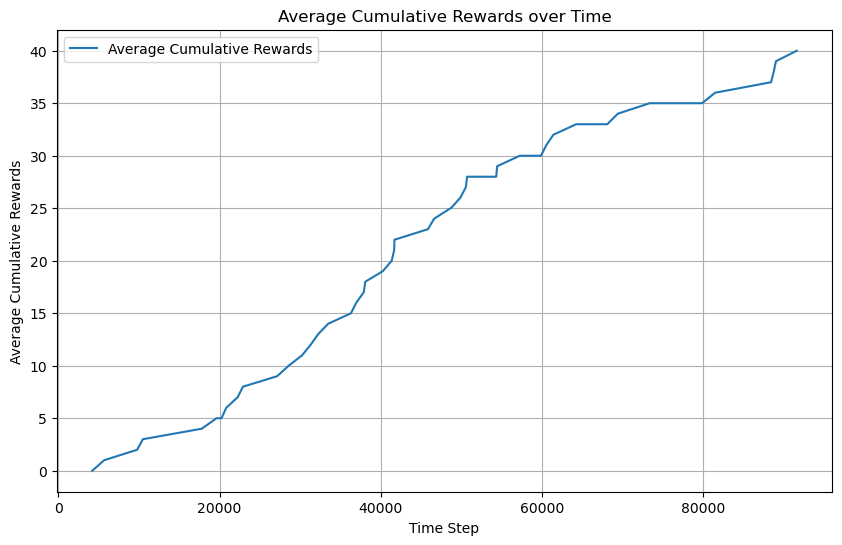

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(evaluation_df['time_step'], evaluation_df['cumulative_rewards'], label='Average Cumulative Rewards')
plt.xlabel('Time Step')
plt.ylabel('Average Cumulative Rewards')
plt.title('Average Cumulative Rewards over Time')
plt.legend()
plt.grid(True)
plt.show()

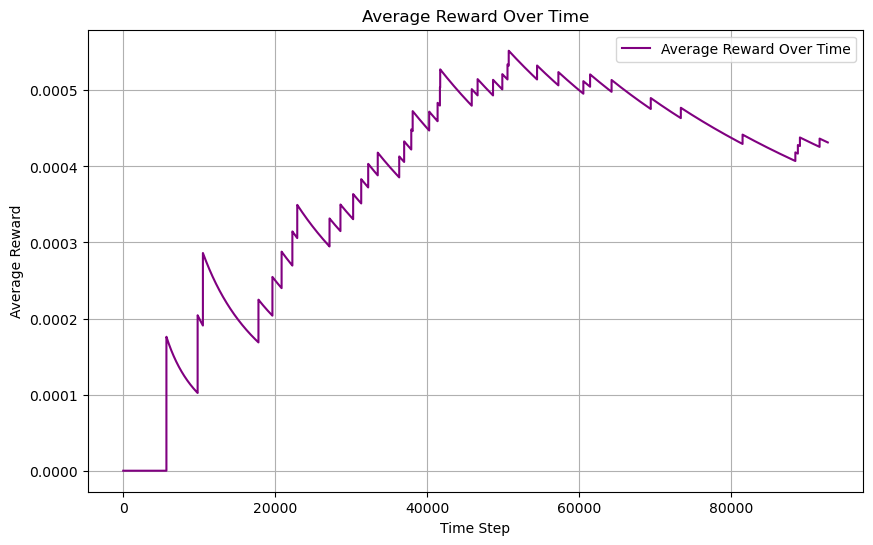

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(average_rewards) + 1), average_rewards, label='Average Reward Over Time', color='purple')
plt.xlabel('Time Step')
plt.ylabel('Average Reward')
plt.title('Average Reward Over Time')
plt.legend()
plt.grid(True)
plt.show() #seems liek the same thing

<h2>LinUCB Algo</h2>

In [17]:
class LinearUCB:
    def __init__(self, n_arms, n_features, alpha=0.001): 
        self.n_arms = n_arms
        self.n_features = n_features
        self.alpha = alpha  # UCB exploration parameter
        
        self.A = [np.identity(n_features) for _ in range(n_arms)]  # Covariance matrix for each arm
        self.b = [np.zeros(n_features) for _ in range(n_arms)]  # Reward vector for each arm
        
    def select_arm(self, context):
        ucb_values = np.zeros(self.n_arms)

        for arm in range(self.n_arms):
            A_inv = np.linalg.inv(self.A[arm])
            theta = np.dot(A_inv, self.b[arm])  # Feature weights for this arm
            
            # Compute the Upper Confidence Bound (UCB) for each arm
            sigma = np.sqrt(np.dot(context, np.dot(A_inv, context)))  # Context-based uncertainty for the arm
            ucb_values[arm] = np.dot(theta, context) + self.alpha * sigma

        # Select the arm with the highest UCB value
        return np.argmax(ucb_values)

    def update(self, context, chosen_arm, reward):
        self.A[chosen_arm] += np.outer(context, context)  # Update covariance matrix (outer product)
        self.b[chosen_arm] += reward * context  # Update reward vector

In [18]:
# Initialize the Linear UCB algorithm
n_arms1 = 10  # Number of arms (movies)
n_features = len(features_columns)  # Number of features (from the data)
alpha = 0.001  # Exploration parameter
algorithm = LinearUCB(n_arms=n_arms1, n_features=n_features, alpha=alpha)

# Initialize an empty list to track evaluation results
evaluation = []
average_rewards = []
cumulative_rewards = 0
iteration_count = 0
row_count = 1

In [19]:
# Iterate over each row in the DataFrame
for i, row in data_with_features.iterrows():
    # Create the context as a tuple of the relevant features
    context = np.array([row[data_with_features.columns.get_loc(col)] for col in features_columns])
    
    if iteration_count > 1000:  # Optional: Stop after 1000 iterations
        break
    
    # Get a recommendation (select an arm) from the algorithm based on the context
    selected_arm = algorithm.select_arm(context)
    
    # Get the actual arm and reward from the data
    actual_arm = row['item_id']
    reward = row['reward']  # Assuming 'reward' is the reward column

    # Check if the recommendation matches the actual arm
    if selected_arm == actual_arm:
        cumulative_rewards += reward 
        evaluation.append({
            'time_step': row_count,  # Time step based on the loop iteration
            'chosen_arm': selected_arm,
            'reward': reward, 
            'cumulative_rewards': cumulative_rewards,
        })
        row_count += 1
        
        # Update the algorithm with the observed reward
        algorithm.update(context, selected_arm, reward)
        # Calculate the average reward up to this iteration
        average_reward = cumulative_rewards / (row_count)
        average_rewards.append(average_reward)

In [20]:
# Convert evaluation results to a DataFrame for analysis
evaluation_df = pd.DataFrame(evaluation)
evaluation_df.head()

,time_step,chosen_arm,reward,cumulative_rewards
0,1,0,1,1
1,2,0,1,2
2,3,0,1,3
3,4,0,1,4
4,5,0,1,5


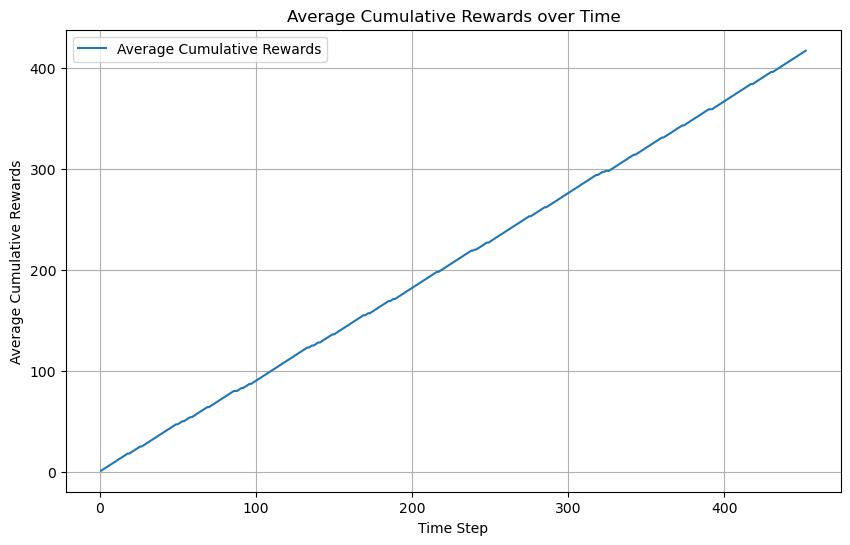

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(evaluation_df['time_step'], evaluation_df['cumulative_rewards'], label='Average Cumulative Rewards')
plt.xlabel('Time Step')
plt.ylabel('Average Cumulative Rewards')
plt.title('Average Cumulative Rewards over Time')
plt.legend()
plt.grid(True)
plt.show()

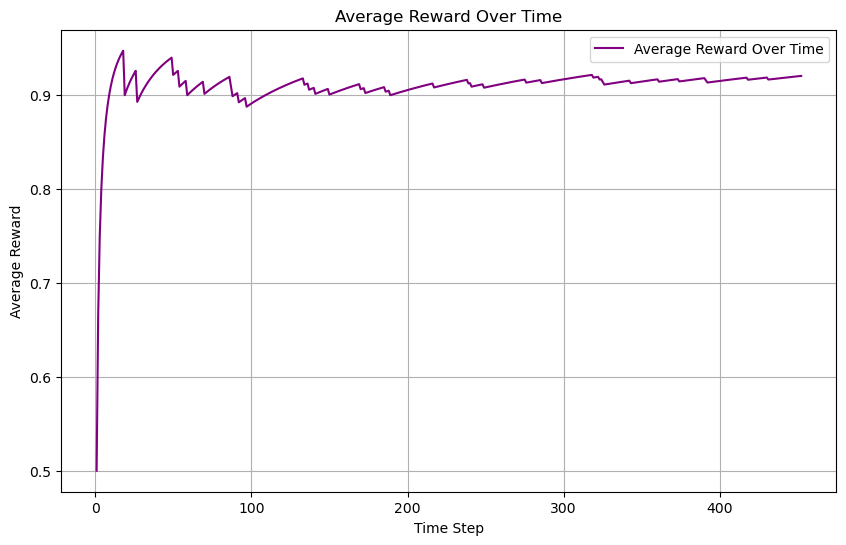

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(average_rewards) + 1), average_rewards, label='Average Reward Over Time', color='purple')
plt.xlabel('Time Step')
plt.ylabel('Average Reward')
plt.title('Average Reward Over Time')
plt.legend()
plt.grid(True)
plt.show() #seems liek the same thing

<h2>Annealing Softmax</h2>

In [23]:
class ContextualSoftmaxAnnealing:
    def __init__(self, n_arms, initial_temperature=1.0, min_temperature=0.1, decay_rate=0.99): 
        self.n_arms = n_arms
        self.initial_temperature = initial_temperature
        self.min_temperature = min_temperature
        self.decay_rate = decay_rate
        self.context_counts = {}  # Store counts for each arm-context pair
        self.context_values = {}  # Store values for each arm-context pair
        self.temperature = initial_temperature  # Initial temperature for softmax annealing
        self.time_step = 0  # Track the number of actions taken (or time steps)

    def initialize_context(self, context):
        # Initialize counts and values for a new context
        if context not in self.context_counts:
            self.context_counts[context] = [0 for _ in range(self.n_arms)]
            self.context_values[context] = [0.0 for _ in range(self.n_arms)]

    def select_arm(self, context, features):
        # Ensure the context is initialized
        if context not in self.context_counts:
            self.initialize_context(context)

        # Anneal the temperature (decrease over time)
        # Decay the temperature at each step
        self.temperature = max(self.min_temperature, self.initial_temperature * (self.decay_rate ** self.time_step))

        # Calculate scores for each arm based on the stored values
        values = np.array([self.context_values[context][arm] for arm in range(self.n_arms)])

        # Softmax calculation: exponentiated values scaled by temperature
        exp_values = np.exp(values / self.temperature)
        probabilities = exp_values / np.sum(exp_values)

        # Select the arm based on the softmax probabilities
        chosen_arm = np.random.choice(self.n_arms, p=probabilities)

        # Increment the time step after each action
        self.time_step += 1

        return chosen_arm

    def update(self, context, chosen_arm, reward):
        # Ensure the context is initialized
        if context not in self.context_counts:
            self.initialize_context(context)

        # Update counts and values for the chosen arm in the given context
        counts = self.context_counts[context]
        values = self.context_values[context]
        
        counts[chosen_arm] += 1
        n = counts[chosen_arm]
        value = values[chosen_arm]
        new_value = ((n - 1) / float(n)) * value + (1 / float(n)) * reward
        values[chosen_arm] = new_value

In [24]:
context_columns = ['user_id', 'item_id', 'timestamp', 'young', 'gender', 'occupation_administrator', 'occupation_artist', 
    'occupation_doctor', 'occupation_educator', 'occupation_engineer', 'occupation_entertainment', 
    'occupation_executive', 'occupation_healthcare', 'occupation_homemaker', 'occupation_lawyer', 
    'occupation_librarian', 'occupation_marketing', 'occupation_none', 'occupation_other', 'occupation_programmer', 
    'occupation_retired', 'occupation_salesman', 'occupation_scientist', 'occupation_student', 
    'occupation_technician', 'occupation_writer']
features_columns = ['movie_id', 'Action', 'Adventure', 'Animation', "Children's", 
    'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 
    'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
my_n_features = n_features
# Initialize the algorithm
algorithm = ContextualSoftmaxAnnealing(n_arms=n_arms)

# Initialize an empty list to track evaluation results
evaluation = []
#context_columns = [col for col in data_with_features.columns if col != 'reward']

cumulative_rewards = 0

# Iterate over each row in the DataFrame
for i, row in data_with_features.iterrows():
    # Create the context as a tuple of the relevant features
    context = tuple(row[data_with_features1.columns.get_loc(col)] for col in context_columns)
    features = tuple(row[data_with_features1.columns.get_loc(col)] for col in features_columns)
    
    # Initialize context in the algorithm
    algorithm.initialize_context(context)

    # Get a recommendation (select an arm) from the algorithm based on the context
    selected_arm = algorithm.select_arm(context,features)
    
    # Get the actual arm and reward from the data
    actual_arm = row['item_id'] - 1  # Adjust if `item_id` is not zero-indexed
    reward = row['reward']  # Assuming 'reward' is the reward column

    # Debug print statements to inspect values
    #print(f"Step {i+1}")
    #print(f"Context: {context}")
    #print(f"Selected Arm: {selected_arm}, Actual Arm: {actual_arm}, Reward: {reward}")

    # Check if the recommendation matches the actual arm
    if selected_arm == actual_arm:
        cumulative_rewards += reward 
        evaluation.append({
            'time_step': i + 1,# Time step based on the loop iteration
            'chosen_arm': selected_arm,
            'reward': reward, 
            'cumulative_rewards': cumulative_rewards,
        })
        
        # Update the algorithm with the observed reward
        algorithm.update(context, selected_arm, reward)

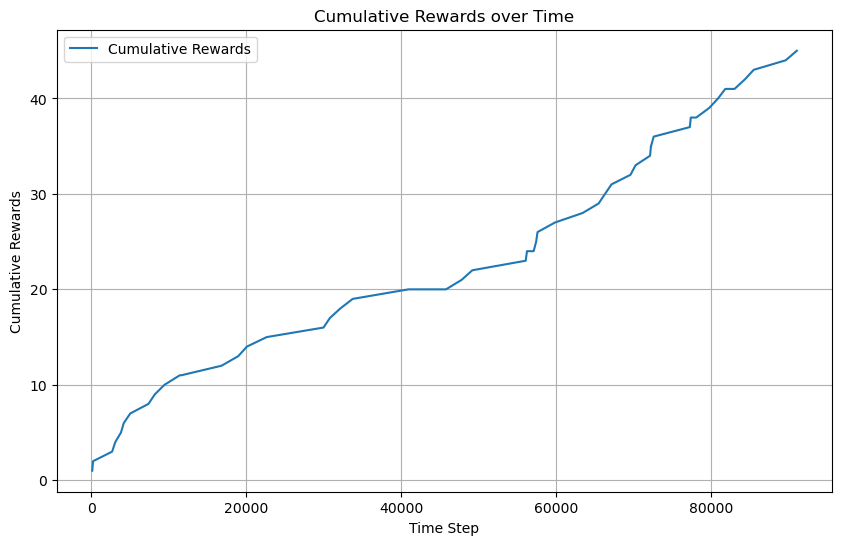

In [25]:
evaluation_df = pd.DataFrame(evaluation)
evaluation_df.head()

plt.figure(figsize=(10, 6))
plt.plot(evaluation_df['time_step'], evaluation_df['cumulative_rewards'], label='Cumulative Rewards')
plt.xlabel('Time Step')
plt.ylabel('Cumulative Rewards')
plt.title('Cumulative Rewards over Time')
plt.legend()
plt.grid(True)
plt.show()

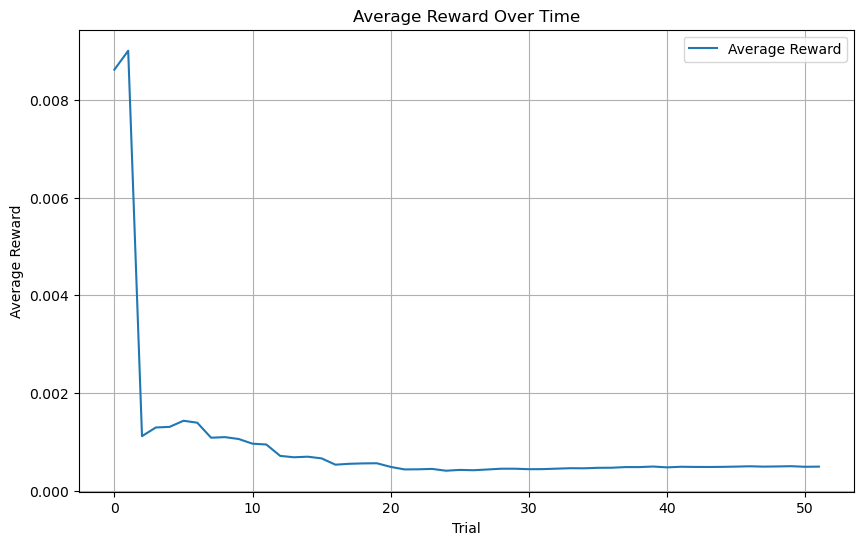

In [26]:
average_rewards = evaluation_df['cumulative_rewards'] / (evaluation_df['time_step'] + 1)  # +1 to avoid division by zero at step 0

# Plotting the average rewards over time
plt.figure(figsize=(10, 6))
plt.plot(average_rewards, label='Average Reward')
plt.xlabel('Trial')
plt.ylabel('Average Reward')
plt.title('Average Reward Over Time')
plt.legend()
plt.grid(True)
plt.show()

<h2>Thompson Sampling Ver 1</h2>
<p>1. Adapting exploration based on confidence</p>
<p>2. Capture complex user-movie feature relationships </p>
<p>3. Learn from continuous ratings</p>

<h3>DO NOT RUN THE TS CODE AS IT CAN TAKE UP TO 10 HOURS TO RUN</h3>

In [1]:
class ContextualThompsonSampling:
    def __init__(self, n_arms, n_features, init_alpha=1, init_beta=1):
        self.n_arms = n_arms
        self.n_features = n_features
        # Prior variance for each arm (not directly used but sets initial scaling)
        self.alpha = init_alpha
        self.beta = init_beta

        # Initialize parameter matrices for each arm
        self.A = [np.identity(n_features) for _ in range(
            n_arms)]  # Covariance matrix for each arm
        # Weighted reward vector for each arm
        self.b = [np.zeros(n_features) for _ in range(n_arms)]

        # Track number of pulls for each arm
        self.counts = [0 for _ in range(n_arms)]

    def select_arm(self, contexts):
        samples = []
        sampled_thetas = np.empty((self.n_arms, self.n_features))

        for arm in range(self.n_arms):
            # Compute adaptive alpha based on number of pulls
            adaptive_alpha = self.alpha / (1 + self.counts[arm])

            # Compute posterior distribution parameters for this arm
            A_inv = np.linalg.inv(self.A[arm])
            # Posterior mean of theta for this arm
            theta_mean = A_inv @ self.b[arm]
            # Scale covariance based on pulls and beta
            # Posterior covariance of theta for this arm
            theta_cov = adaptive_alpha * self.beta * A_inv

            # Sample theta from the posterior distribution
            theta_sample = np.random.multivariate_normal(theta_mean, theta_cov)
            sampled_thetas[arm] = theta_sample

            # Calculate the expected reward for the current context of this arm
            p_arm = contexts[arm].dot(theta_sample)
            samples.append(p_arm)

        scores = np.array(samples)
        # Choose the arm with the highest expected reward based on the sampled theta
        best_arm = np.argmax(samples)
        return best_arm, sampled_thetas, scores
    
    def update(self, chosen_arm, context, reward):
        # Update counts
        self.counts[chosen_arm] += 1
        
        # Update A and b for the chosen arm
        self.A[chosen_arm] += np.outer(context, context)
        self.b[chosen_arm] += reward * context

        # Update beta for exploration-exploitation trade-off
        self.beta = max(0.5, self.beta * (1 - 1/(1 + self.counts[chosen_arm])))

In [ ]:
n_arms = subsampled_u_item['movie_id'].nunique()
n_features = data_with_features.shape[1] - 4  # exclude 'user_id', 'item_id', 'rating', 'timestamp'
cts = ContextualThompsonSampling(n_arms=n_arms, n_features=n_features)

contextual_matrix = np.zeros((len(data_with_features), n_arms, n_features))

# Before processing, convert any boolean columns to integers
feature_matrix = data_with_features.copy()
bool_columns = feature_matrix.select_dtypes(include=['bool']).columns
for col in bool_columns:
    feature_matrix[col] = feature_matrix[col].astype(int)

iteration_count = 0
for _, row in data_with_features.iterrows():
    
    # Extract user context and arm information
    user_context = row.drop(['user_id', 'item_id', 'rating', 'timestamp', 'reward']).values.astype(np.float64)
    arm = row['item_id']
    reward = row['reward']
    mapped_arm = arm_mapping[arm]
    
    # Add the user context to the contextual matrix
    contextual_matrix[iteration_count, mapped_arm, :] = user_context

    # Get recommendation using Thompson Sampling
    contexts = contextual_matrix[iteration_count]  # Get all arm contexts for this iteration
    chosen_arm, sampled_thetas, scores = cts.select_arm(contexts)
     
    # Check if the chosen arm matches the actual arm for logging reward
    if chosen_arm == mapped_arm:
        # Update bandit with observed reward
        cts.update(chosen_arm, contextual_matrix[iteration_count][chosen_arm], reward)
    
    # Increment the iteration counter
    iteration_count += 1

In [ ]:
def replay_evaluation(data_with_features, ts_bandit, contextual_matrix):
    step = 0  # Counter for matched plays
    evaluation = []
    n_trials = len(data_with_features)
    
    # Initialize storage arrays
    theta_history = np.empty(shape=(n_trials, ts_bandit.n_arms, ts_bandit.n_features))
    score_history = np.empty(shape=(n_trials, ts_bandit.n_arms))
    reward_history = np.empty(n_trials)
    chosen_arms_history = np.empty(n_trials)
    cumulative_rewards = 0

    alpha_history = np.empty(shape=(n_trials, ts_bandit.n_arms))
    beta_history = np.empty(n_trials)
    counts_history = np.empty(shape=(n_trials, ts_bandit.n_arms))

    # For each logged event
    for i, row in data_with_features.iterrows():
        # Get current context and logged action
        user_context = contextual_matrix[i]
        logged_action = arm_mapping[row['item_id']]  # Map item_id to internal arm index
        logged_reward = row['reward']
        
        # Get recommendation from Thompson Sampling
        chosen_arm, sampled_thetas, scores = ts_bandit.select_arm(user_context)
        
        # If recommended action matches logged action
        if chosen_arm == logged_action:
            # Store histories
            theta_history[step] = sampled_thetas
            score_history[step] = scores
            reward_history[step] = logged_reward
            chosen_arms_history[step] = chosen_arm
            
            alpha_history[step] = [ts_bandit.alpha / (1 + count) for count in ts_bandit.counts]
            beta_history[step] = ts_bandit.beta
            counts_history[step] = ts_bandit.counts
            
            cumulative_rewards += logged_reward 
            evaluation.append({
            'time_step': i + 1, # Time step based on the loop iteration
            'chosen_arm': logged_action,
            'reward': logged_reward, 
            'cumulative_rewards': cumulative_rewards,
            'current_alpha': ts_bandit.alpha / (1 + ts_bandit.counts[chosen_arm]),
            'current_beta': ts_bandit.beta,
            'arm_pulls': ts_bandit.counts[chosen_arm]
        })
        
            # Update bandit with logged reward
            ts_bandit.update(chosen_arm, user_context[chosen_arm], logged_reward)
            step += 1
            
    # Calculate metrics
    cumulative_rewards = np.cumsum(reward_history[:step])
    average_rewards = cumulative_rewards / (np.arange(step) + 1)
    
    # Calculate arm selection frequencies
    arm_counts = np.bincount(chosen_arms_history[:step].astype(int), 
                           minlength=ts_bandit.n_arms)
    arm_frequencies = arm_counts / step
    
    return {
        'evaluation': evaluation,
        'theta_history': theta_history[:step],
        'score_history': score_history[:step],
        'reward_history': reward_history[:step],
        'chosen_arms_history': chosen_arms_history[:step],
        'cumulative_rewards': cumulative_rewards,
        'average_rewards': average_rewards,
        'arm_frequencies': arm_frequencies,
        'alpha_history': alpha_history[:step],
        'beta_history': beta_history[:step],
        'counts_history': counts_history[:step],
        'evaluation_records': evaluation,
        'total_matches': step
    }

In [ ]:
ts_bandit = ContextualThompsonSampling(n_arms=n_arms, n_features=n_features)
replay_results = replay_evaluation(data_with_features, ts_bandit, contextual_matrix)
evaluation_df = pd.DataFrame(replay_results['evaluation'])
evaluation_df.to_csv('evaluation_results.csv', index=False)

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(evaluation_df['time_step'], evaluation_df['cumulative_rewards'], label='Average Cumulative Rewards')
plt.xlabel('Time Step')
plt.ylabel('Average Cumulative Rewards')
plt.title('Average Cumulative Rewards over Time')
plt.legend()
plt.grid(True)
plt.show()


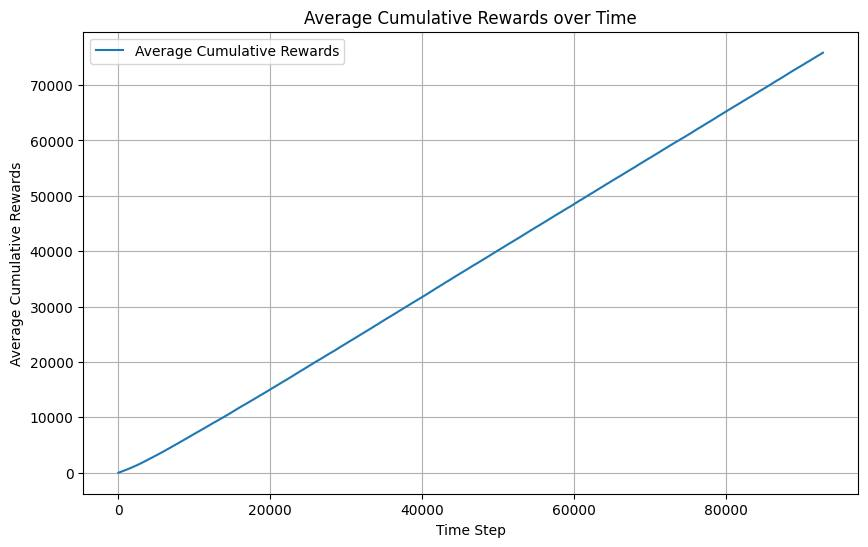

In [5]:
# Specify the image path
image_path = 'avg_cum_ts.jpg'

# Display the image
display(Image(filename=image_path))

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(replay_results['average_rewards'], label='Average Reward', color='green')
plt.xlabel('Trial')
plt.ylabel('Average Reward')
plt.title('Average Reward over Time')
plt.legend()
plt.show()


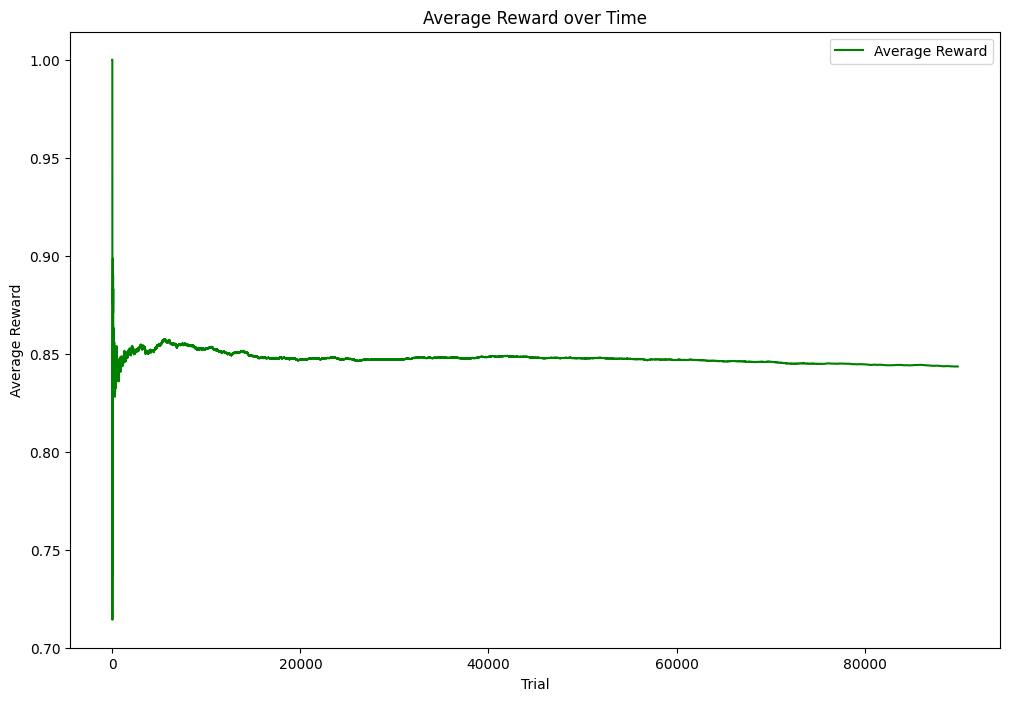

In [6]:
# Specify the image path
image_path = 'avg_rew_ts.jpg'

# Display the image
display(Image(filename=image_path))

<h2>Thompson Sampling Ver 2</h2>
<p>limit to 1000 steps due to performance</p>

In [ ]:
class ThompsonSampling:
    def __init__(self, n_arms, n_features, alpha=1, beta=1):
        self.n_arms = n_arms
        self.n_features = n_features
        self.alpha = alpha  # Prior alpha for Beta distribution (used in Bernoulli reward model)
        self.beta = beta    # Prior beta for Beta distribution
        
        # Initialize parameters for each arm (movie)
        self.successes = np.zeros(n_arms)  # Successful outcomes (reward = 1)
        self.failures = np.zeros(n_arms)   # Failure outcomes (reward = 0)
        
        self.context_values = {}  # Store feature weights for each arm-context pair

    def initialize_context(self, context):
        if context not in self.context_values:
            self.context_values[context] = np.zeros(self.n_arms)  # Initialize feature weights for each arm

    def select_arm(self, context, features):
        # Ensure the context is initialized
        if context not in self.context_values:
            self.initialize_context(context)
        
        # Get the context's feature weights
        feature_weights = self.context_values[context]

        # Thompson Sampling: Sample from the posterior distribution for each arm
        theta_samples = np.zeros(self.n_arms)
        for arm in range(self.n_arms):
            # For a Bernoulli reward, we assume a Beta distribution prior and posterior
            success = self.successes[arm]
            failure = self.failures[arm]
            
            # Sample from the Beta distribution (posterior distribution of the arm's reward)
            theta_samples[arm] = np.random.beta(success + self.alpha, failure + self.beta)
        
        # Select the arm with the highest sampled theta
        return np.argmax(theta_samples)

    def update(self, context, chosen_arm, reward, features):
        """Update the algorithm with the observed reward for the chosen arm."""
        # Ensure the context is initialized
        if context not in self.context_values:
            self.initialize_context(context)

        # Update the successes or failures based on the observed reward
        if reward > 0:
            self.successes[chosen_arm] += 1
        else:
            self.failures[chosen_arm] += 1

        # Update feature weights for the chosen arm using observed feedback
        feature_weights = self.context_values[context]
        feature_weights[chosen_arm] = (self.successes[chosen_arm] / 
                                      (self.successes[chosen_arm] + self.failures[chosen_arm]))  # Example update rule

In [ ]:
# Initialize the Thompson Sampling algorithm
n_features = len(features_columns)  # Number of features (from the data)
algorithm = ThompsonSampling(n_arms=n_arms, n_features=n_features)

# Initialize an empty list to track evaluation results
evaluation = []
average_rewards = []
cumulative_rewards = 0
iteration_count = 0
row_count = 1

# Iterate over each row in the DataFrame
for i, row in data_with_features.iterrows():
    # Create the context as a tuple of the relevant features
    context = tuple(row[data_with_features.columns.get_loc(col)] for col in context_columns)
    features = np.array([row[data_with_features.columns.get_loc(col)] for col in features_columns])

    if iteration_count > 1000:
        break

    # Initialize context in the algorithm
    algorithm.initialize_context(context)

    # Get a recommendation (select an arm) from the algorithm based on the context
    selected_arm = algorithm.select_arm(context, features)
    
    # Get the actual arm and reward from the data
    actual_arm = row['item_id']
    reward = row['reward']  # Assuming 'reward' is the reward column

    # Check if the recommendation matches the actual arm
    if selected_arm == actual_arm:
        cumulative_rewards += reward
        evaluation.append({
            'time_step': row_count,  # Time step based on the loop iteration
            'chosen_arm': selected_arm,
            'reward': reward, 
            'cumulative_rewards': cumulative_rewards,
        })
        row_count += 1
        
        # Update the algorithm with the observed reward
        algorithm.update(context, selected_arm, reward, features)

    average_reward = cumulative_rewards / (i + 1)
    average_rewards.append(average_reward)

# Convert evaluation results to a DataFrame for analysis
evaluation_df = pd.DataFrame(evaluation)
evaluation_df.head()